In [9]:
# Phase 2: Unsupervised Regime Identification via Causal TCN Autoencoder + Gaussian HMM
# Input:  tvpvar_connectedness_FILTERED.csv  (22 TVP-VAR connectedness features)
# Output: hmm_regimes.csv  (daily HMM state labels → input for Phase 3)

## 1. Data Ingestion & Pre-TCN Smoothing

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'hmmlearn', '-q'], check=True)
print("hmmlearn installed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
hmmlearn installed.


In [11]:
import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

BASE = "/content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability"

INPUT_PATH  = os.path.join(BASE, "TVP-VAR MODEL/outputs", "tvpvar_connectedness_FILTERED.csv")
OUTPUT_DIR  = os.path.join(BASE, "HMM-TCN")
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "hmm_regimes.csv")
MODEL_PATH  = os.path.join(OUTPUT_DIR, "tcn_autoencoder_best.pt")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input  : {INPUT_PATH}")
print(f"Output : {OUTPUT_DIR}")

Input  : /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/TVP-VAR MODEL/outputs/tvpvar_connectedness_FILTERED.csv
Output : /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/HMM-TCN


In [12]:
df_raw = pd.read_csv(INPUT_PATH, parse_dates=['Date'], index_col='Date')

print(f"Shape      : {df_raw.shape}  ({df_raw.shape[0]} trading days × {df_raw.shape[1]} features)")
print(f"Date range : {df_raw.index.min().date()}  →  {df_raw.index.max().date()}")
print(f"Missing    : {df_raw.isnull().sum().sum()}")
df_raw.head(3)

Shape      : (5967, 22)  (5967 trading days × 22 features)
Date range : 2002-01-16  →  2024-12-31
Missing    : 0


,TCI,TO_JCI,TO_SP500,TO_SSE,TO_VIX,TO_WTI,TO_Gold,TO_USDIDR,FROM_JCI,FROM_SP500,...,FROM_WTI,FROM_Gold,FROM_USDIDR,NET_JCI,NET_SP500,NET_SSE,NET_VIX,NET_WTI,NET_Gold,NET_USDIDR
Date,,,,,,,,,,,,,,,,,,,,,
2002-01-16,34.566543,0.323184,0.681437,0.135135,30.486271,0.735951,0.522591,1.681974,6.476720,11.279519,...,7.955259,2.195882,0.331785,-6.153536,-10.598082,-6.140960,30.434987,-7.219308,-1.673291,1.350189
2002-01-17,83.914141,12.761197,12.028626,12.982097,13.031045,11.795624,12.572437,8.743115,12.038804,12.156102,...,12.261082,12.010694,11.479626,0.722393,-0.127476,0.948584,1.096725,-0.465458,0.561743,-2.736510
2002-01-18,77.706197,3.465390,5.656373,15.044289,15.653082,10.646647,15.298787,11.941628,11.028518,13.195446,...,10.580568,10.744673,10.561813,-7.563128,-7.539072,4.302297,4.799895,0.066079,4.554114,1.379816


In [13]:
# 5-day rolling mean to suppress microstructural noise (1 trading week)
SMOOTH_WINDOW = 5

df_smooth = df_raw.rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW).mean()
df_smooth.dropna(inplace=True)

print(f"After smoothing — shape : {df_smooth.shape}")
print(f"Date range              : {df_smooth.index.min().date()}  →  {df_smooth.index.max().date()}")

After smoothing — shape : (5963, 22)
Date range              : 2002-01-22  →  2024-12-31


In [14]:
# Scaler is fitted only on the training slice (after split) to avoid look-ahead bias
scaler = MinMaxScaler(feature_range=(0, 1))
data_raw      = df_smooth.values
feature_names = df_smooth.columns.tolist()
T, n_features = data_raw.shape

print(f"Raw data shape : {data_raw.shape}")

Raw data shape : (5963, 22)


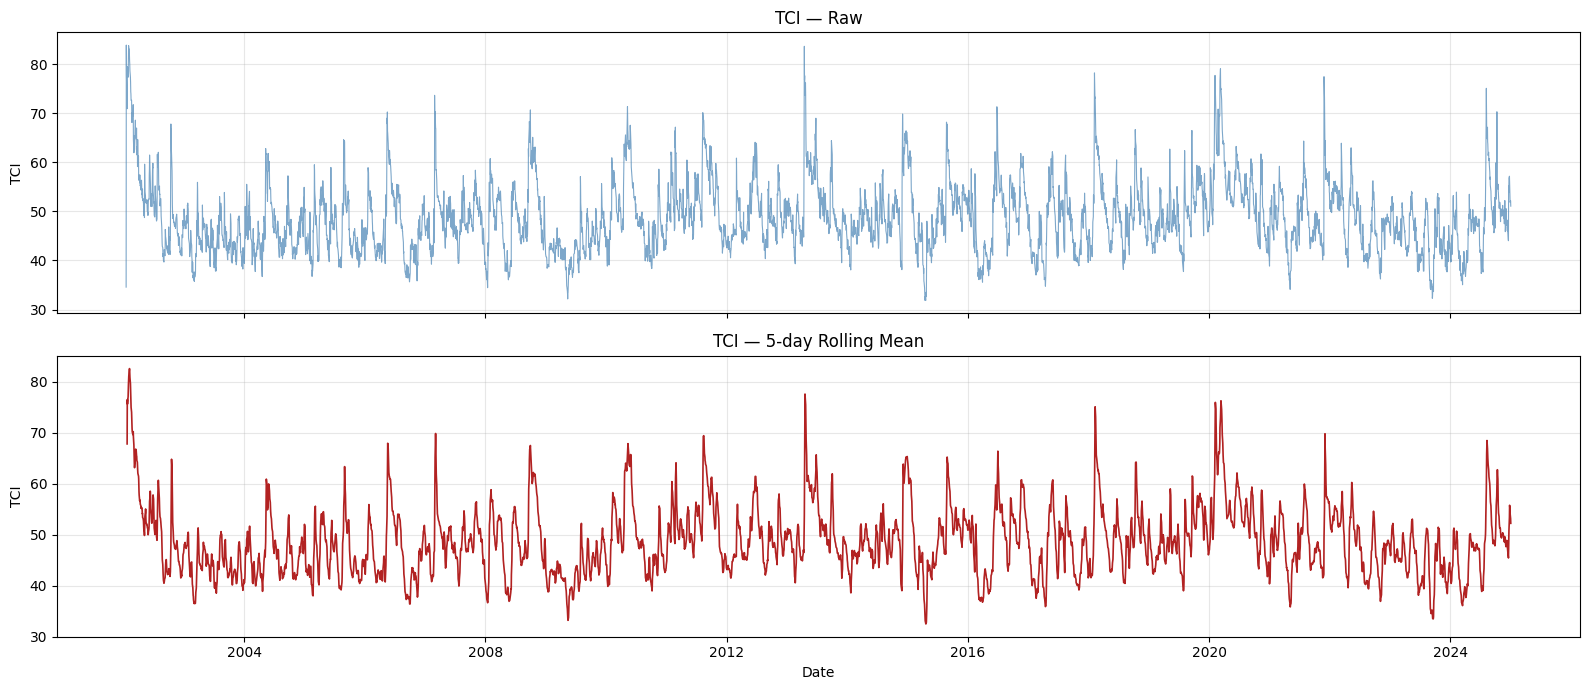

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_raw.index, df_raw['TCI'], color='steelblue', lw=0.8, alpha=0.7)
axes[0].set_title('TCI — Raw', fontsize=12)
axes[0].set_ylabel('TCI')
axes[0].grid(alpha=0.3)

axes[1].plot(df_smooth.index, df_smooth['TCI'], color='firebrick', lw=1.2)
axes[1].set_title(f'TCI — {SMOOTH_WINDOW}-day Rolling Mean', fontsize=12)
axes[1].set_ylabel('TCI')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ch1_tci_smoothing_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Causal TCN Autoencoder

In [16]:
LOOKBACK   = 60   # ~3 trading months
BATCH_SIZE = 64   # standard mini-batch size; balances gradient stability and memory usage

class ConnectednessDataset(Dataset):
    def __init__(self, data: np.ndarray, lookback: int):
        self.data     = torch.tensor(data, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.data) - self.lookback + 1

    def __getitem__(self, idx):
        seq = self.data[idx : idx + self.lookback]
        return seq, seq  # autoencoder: target == input


# Chronological 80/20 split
split_idx = int(T * 0.80)
train_raw = data_raw[:split_idx]
val_raw   = data_raw[split_idx:]

# Fit scaler on training data only
scaler.fit(train_raw)
train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
data_scaled  = scaler.transform(data_raw)

print(f"Train : {train_raw.shape[0]} days  |  Val : {val_raw.shape[0]} days")
print(f"Train scaled range : [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")
print(f"Val   scaled range : [{val_scaled.min():.4f}, {val_scaled.max():.4f}]")

train_dataset = ConnectednessDataset(train_scaled, LOOKBACK)
val_dataset   = ConnectednessDataset(val_scaled,   LOOKBACK)
full_dataset  = ConnectednessDataset(data_scaled,  LOOKBACK)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
full_loader  = DataLoader(full_dataset,  batch_size=128,        shuffle=False)

print(f"\nTrain samples : {len(train_dataset)}  |  Val samples : {len(val_dataset)}  |  Full : {len(full_dataset)}")

Train : 4770 days  |  Val : 1193 days
Train scaled range : [0.0000, 1.0000]
Val   scaled range : [-0.0826, 0.9460]

Train samples : 4711  |  Val samples : 1134  |  Full : 5904


In [17]:
# Model hyperparameters
NUM_FILTERS = 16    # narrow channel width; keeps model compact, limits noise memorisation
LATENT_DIM  = 4     # bottleneck dimension; minimum needed to separate HMM regime clusters
KERNEL_SIZE = 3     # small kernel; combined with exponential dilation achieves wide receptive field
DROPOUT     = 0.3   # applied inside each residual block to regularise temporal features
DILATIONS   = [1, 2, 4, 8]  # exponential dilation → receptive field covers LOOKBACK


class CausalConvBlock(nn.Module):
    """Causal dilated residual block. Input/output: (batch, channels, time)."""
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.3):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.pad1  = nn.ConstantPad1d((pad, 0), 0)
        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel_size, dilation=dilation)
        self.norm1 = nn.BatchNorm1d(out_ch)
        self.pad2  = nn.ConstantPad1d((pad, 0), 0)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation)
        self.norm2 = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.relu  = nn.ReLU(inplace=True)
        self.proj  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.proj(x)
        out = self.relu(self.norm1(self.conv1(self.pad1(x))))
        out = self.drop(out)
        out = self.relu(self.norm2(self.conv2(self.pad2(out))))
        out = self.drop(out)
        return self.relu(out + res)


class TCNAutoencoder(nn.Module):
    """
    Encoder: CausalConvBlocks → AdaptiveAvgPool → Linear → latent (LATENT_DIM,)
    Decoder: Linear → reshape → CausalConvBlocks → Conv1d + Sigmoid → reconstruction
    Input/output shape: (batch, LOOKBACK, n_features)
    """
    def __init__(self, n_features, lookback, num_filters, latent_dim, kernel_size, dilations, dropout):
        super().__init__()
        self.n_features  = n_features
        self.lookback    = lookback
        self.latent_dim  = latent_dim
        self.num_filters = num_filters

        enc_layers = []
        in_ch = n_features
        for d in dilations:
            enc_layers.append(CausalConvBlock(in_ch, num_filters, kernel_size, d, dropout))
            in_ch = num_filters
        self.encoder_tcn = nn.Sequential(*enc_layers)
        self.enc_pool    = nn.AdaptiveAvgPool1d(1)
        self.enc_fc      = nn.Linear(num_filters, latent_dim)

        self.dec_fc  = nn.Linear(latent_dim, num_filters * lookback)
        dec_layers   = []
        in_ch = num_filters
        for d in reversed(dilations):
            dec_layers.append(CausalConvBlock(in_ch, num_filters, kernel_size, d, dropout))
            in_ch = num_filters
        self.decoder_tcn = nn.Sequential(*dec_layers)
        self.dec_out = nn.Sequential(
            nn.Conv1d(num_filters, n_features, 1),
            nn.Sigmoid()  # bound output to [0, 1] — consistent with MinMax-scaled input
        )

    def encode(self, x):
        z = x.permute(0, 2, 1)
        z = self.encoder_tcn(z)
        z = self.enc_pool(z).squeeze(-1)
        return self.enc_fc(z)

    def decode(self, z):
        out = self.dec_fc(z).view(-1, self.num_filters, self.lookback)
        out = self.decoder_tcn(out)
        return self.dec_out(out).permute(0, 2, 1)

    def forward(self, x):
        return self.decode(self.encode(x))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = TCNAutoencoder(
    n_features  = n_features,
    lookback    = LOOKBACK,
    num_filters = NUM_FILTERS,
    latent_dim  = LATENT_DIM,
    kernel_size = KERNEL_SIZE,
    dilations   = DILATIONS,
    dropout     = DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Device: cpu
Trainable parameters: 18,954
TCNAutoencoder(
  (encoder_tcn): Sequential(
    (0): CausalConvBlock(
      (pad1): ConstantPad1d(padding=(2, 0), value=0)
      (conv1): Conv1d(22, 16, kernel_size=(3,), stride=(1,))
      (norm1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pad2): ConstantPad1d(padding=(2, 0), value=0)
      (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,))
      (norm2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop): Dropout(p=0.3, inplace=False)
      (relu): ReLU(inplace=True)
      (proj): Conv1d(22, 16, kernel_size=(1,), stride=(1,))
    )
    (1): CausalConvBlock(
      (pad1): ConstantPad1d(padding=(4, 0), value=0)
      (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), dilation=(2,))
      (norm1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pad2): ConstantPad1d(padding=(4, 0), value=0)
      (conv2): Conv1d(16

In [18]:
# Training config
NUM_EPOCHS    = 300   # upper bound; early stopping will terminate sooner in practice
LEARNING_RATE = 1e-3  # standard Adam learning rate for time-series autoencoders
WEIGHT_DECAY  = 1e-3  # L2 regularisation on all weights; passed to Adam as weight_decay
ES_PATIENCE   = 20    # halt training if val loss does not improve for 20 consecutive epochs

optimizer        = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion        = nn.MSELoss()
train_losses     = []
val_losses       = []
best_val_loss    = float('inf')
patience_counter = 0

print(f"{'Epoch':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Best':>10}")
print("-" * 44)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * x_batch.size(0)
    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_loss_sum += criterion(model(x_val), y_val).item() * x_val.size(0)
    val_loss = val_loss_sum / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        flag = " *" if improved else ""
        print(f"{epoch:>6}  {train_loss:>10.6f}  {val_loss:>10.6f}  {best_val_loss:>10.6f}{flag}")

    if patience_counter >= ES_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  (patience={ES_PATIENCE})")
        break

model.load_state_dict(torch.load(MODEL_PATH))
print(f"\nBest model loaded  (val MSE = {best_val_loss:.6f})")

 Epoch   Train MSE     Val MSE        Best
--------------------------------------------
     1    0.053629    0.030729    0.030729 *
    10    0.012889    0.015257    0.015257 *
    20    0.012454    0.013984    0.013984 *
    30    0.012525    0.014357    0.013984
    40    0.012531    0.013773    0.013749
    50    0.012535    0.013824    0.013525
    60    0.012521    0.013953    0.013525

Early stopping at epoch 68  (patience=20)

Best model loaded  (val MSE = 0.013525)


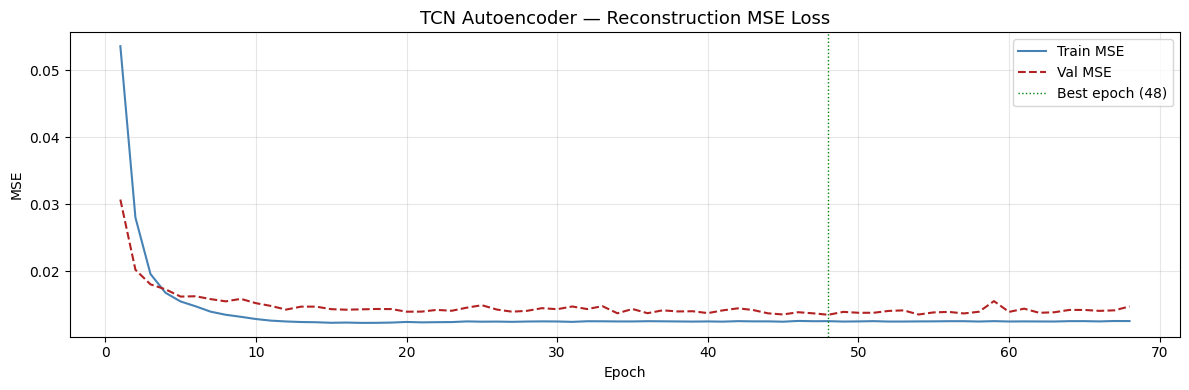

In [19]:
best_epoch = val_losses.index(min(val_losses)) + 1

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(train_losses) + 1), train_losses, label='Train MSE', color='steelblue', lw=1.5)
ax.plot(range(1, len(val_losses)   + 1), val_losses,   label='Val MSE',   color='firebrick', lw=1.5, linestyle='--')
ax.axvline(x=best_epoch, color='green', lw=1, linestyle=':', label=f'Best epoch ({best_epoch})')
ax.set_title('TCN Autoencoder — Reconstruction MSE Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ch2_tcn_training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
model.eval()
latent_list = []

with torch.no_grad():
    for x_batch, _ in full_loader:
        z = model.encode(x_batch.to(device))
        latent_list.append(z.cpu().numpy())

latent_embeddings = np.vstack(latent_list)  # (T - LOOKBACK + 1, LATENT_DIM)
latent_dates      = df_smooth.index[LOOKBACK - 1:]

print(f"Embeddings shape : {latent_embeddings.shape}")
print(f"Date range       : {latent_dates[0].date()}  →  {latent_dates[-1].date()}")
print(f"Value range      : [{latent_embeddings.min():.4f}, {latent_embeddings.max():.4f}]")

Embeddings shape : (5904, 4)
Date range       : 2002-04-15  →  2024-12-31
Value range      : [-0.2134, 0.1678]


## 3. Latent Space Clustering via Gaussian HMM

In [21]:
def compute_hmm_bic(embeddings: np.ndarray, n_states: int,
                    n_iter: int = 2000, n_restarts: int = 5) -> tuple:
    """
    Fit GaussianHMM with multiple random restarts and return the best model + BIC.
    BIC = -2 * logL + n_params * ln(T)
    n_params = (K-1) + K*(K-1) + K*d + K*d*(d+1)/2
    """
    T_len, d = embeddings.shape
    n_params = (n_states - 1) + n_states * (n_states - 1) + n_states * d + n_states * d * (d + 1) // 2

    best_loglik = -np.inf
    best_model  = None

    for seed in range(n_restarts):
        try:
            hmm = GaussianHMM(
                n_components    = n_states,
                covariance_type = 'full',
                n_iter          = n_iter,
                random_state    = seed * 7,
                tol             = 1e-5,
            )
            hmm.fit(embeddings)
            ll = hmm.score(embeddings)
            if ll > best_loglik:
                best_loglik = ll
                best_model  = hmm
        except Exception:
            continue

    bic = -2 * best_loglik + n_params * math.log(T_len)
    return bic, best_loglik, best_model


def check_persistence(model: GaussianHMM, embeddings: np.ndarray, min_spell: int = 30) -> bool:
    """Return True if every state has mean spell length > min_spell days."""
    states = model.predict(embeddings)
    for k in range(model.n_components):
        mask   = (states == k).astype(int)
        spells, run = [], 0
        for v in mask:
            if v == 1:
                run += 1
            elif run > 0:
                spells.append(run)
                run = 0
        if run > 0:
            spells.append(run)
        if not spells or np.mean(spells) <= min_spell:
            return False
    return True


# BIC search config
K_RANGE   = [2, 3, 4, 5, 6, 7, 8]  # candidate regime counts; winner chosen by BIC
MIN_SPELL = 30  # minimum mean spell length (days) for a valid macroeconomic regime

bic_scores = {}
hmm_models = {}
d          = latent_embeddings.shape[1]

print(f"{'K':>4}  {'Log-Likelihood':>16}  {'n_params':>10}  {'BIC':>14}")
print("-" * 50)

for k in K_RANGE:
    bic, loglik, hmm_model = compute_hmm_bic(latent_embeddings, k)
    n_p = (k - 1) + k * (k - 1) + k * d + k * d * (d + 1) // 2
    print(f"{k:>4}  {loglik:>16.2f}  {n_p:>10}  {bic:>14.2f}")
    hmm_models[k] = hmm_model
    bic_scores[k] = bic

# Select BIC-optimal K, rejecting any K with degenerate states
sorted_ks = sorted(bic_scores, key=bic_scores.get)
optimal_K = None

print(f"\nPersistence guard (min_spell = {MIN_SPELL} days):")
for k_candidate in sorted_ks:
    passes = check_persistence(hmm_models[k_candidate], latent_embeddings, MIN_SPELL)
    if passes:
        optimal_K = k_candidate
        print(f"K={optimal_K} accepted  (BIC={bic_scores[optimal_K]:.2f})")
        break
    else:
        print(f"K={k_candidate} rejected — degenerate state(s) detected")

if optimal_K is None:
    optimal_K = sorted_ks[0]
    print(f"No K passed persistence check — using BIC-best K={optimal_K} as fallback")

   K    Log-Likelihood    n_params             BIC
--------------------------------------------------
   2          44680.33          31       -89091.48
   3          47189.62          50       -93945.06


   4          49464.40          71       -98312.29


   5          50802.92          94      -100789.60


   6          51630.73         119      -102228.14


   7          50892.59         146      -100517.42


   8          53569.13         175      -105618.66

Persistence guard (min_spell = 30 days):
K=8 rejected — degenerate state(s) detected
K=6 rejected — degenerate state(s) detected
K=5 accepted  (BIC=-100789.60)


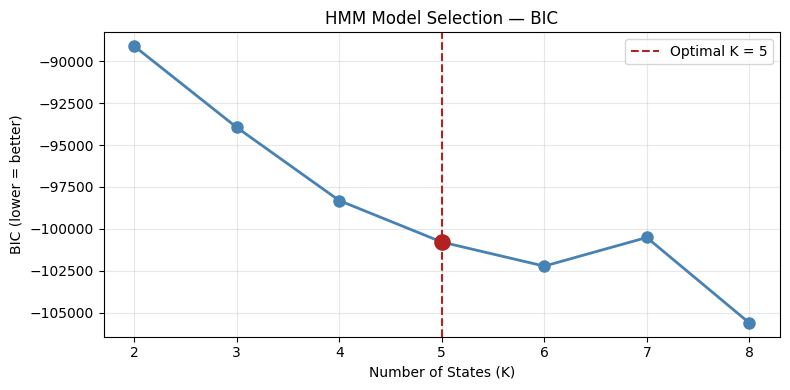

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ks   = list(bic_scores.keys())
bics = list(bic_scores.values())
ax.plot(ks, bics, 'o-', color='steelblue', lw=2, markersize=8)
ax.axvline(x=optimal_K, color='firebrick', linestyle='--', lw=1.5, label=f'Optimal K = {optimal_K}')
ax.scatter([optimal_K], [bic_scores[optimal_K]], color='firebrick', zorder=5, s=120)
ax.set_title('HMM Model Selection — BIC', fontsize=12)
ax.set_xlabel('Number of States (K)')
ax.set_ylabel('BIC (lower = better)')
ax.set_xticks(ks)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ch3_hmm_bic_selection.png'), dpi=150, bbox_inches='tight')
plt.show()

In [23]:
best_hmm       = hmm_models[optimal_K]
viterbi_states = best_hmm.predict(latent_embeddings)

regime_df = pd.DataFrame({'hmm_state': viterbi_states}, index=latent_dates)
regime_df.index.name = 'Date'

print(f"States found : {np.unique(viterbi_states)}")
state_counts = pd.Series(viterbi_states).value_counts().sort_index()
for st, cnt in state_counts.items():
    print(f"  State {st}: {cnt:>5} days  ({cnt/len(viterbi_states)*100:.1f}%)")

States found : [0 1 2 3 4]
  State 0:  1434 days  (24.3%)
  State 1:  1205 days  (20.4%)
  State 2:  1324 days  (22.4%)
  State 3:   940 days  (15.9%)
  State 4:  1001 days  (17.0%)


In [24]:
def compute_spell_stats(states: np.ndarray, n_states: int) -> pd.DataFrame:
    rows = []
    for k in range(n_states):
        mask    = (states == k).astype(int)
        spells  = []
        run_len = 0
        for val in mask:
            if val == 1:
                run_len += 1
            elif run_len > 0:
                spells.append(run_len)
                run_len = 0
        if run_len > 0:
            spells.append(run_len)
        if spells:
            rows.append({
                'State'        : k,
                'Total Days'   : int(mask.sum()),
                'N Spells'     : len(spells),
                'Mean Spell'   : round(np.mean(spells),   1),
                'Median Spell' : round(np.median(spells), 1),
                'Max Spell'    : int(np.max(spells)),
            })
    return pd.DataFrame(rows).set_index('State')


spell_stats = compute_spell_stats(viterbi_states, optimal_K)
print("REGIME PERSISTENCE DIAGNOSTICS")
print(spell_stats.to_string())

REGIME PERSISTENCE DIAGNOSTICS
       Total Days  N Spells  Mean Spell  Median Spell  Max Spell
State                                                           
0            1434        25        57.4          37.0        218
1            1205        31        38.9          39.0         73
2            1324        30        44.1          42.5        143
3             940        19        49.5          42.0        145
4            1001        18        55.6          37.0        239


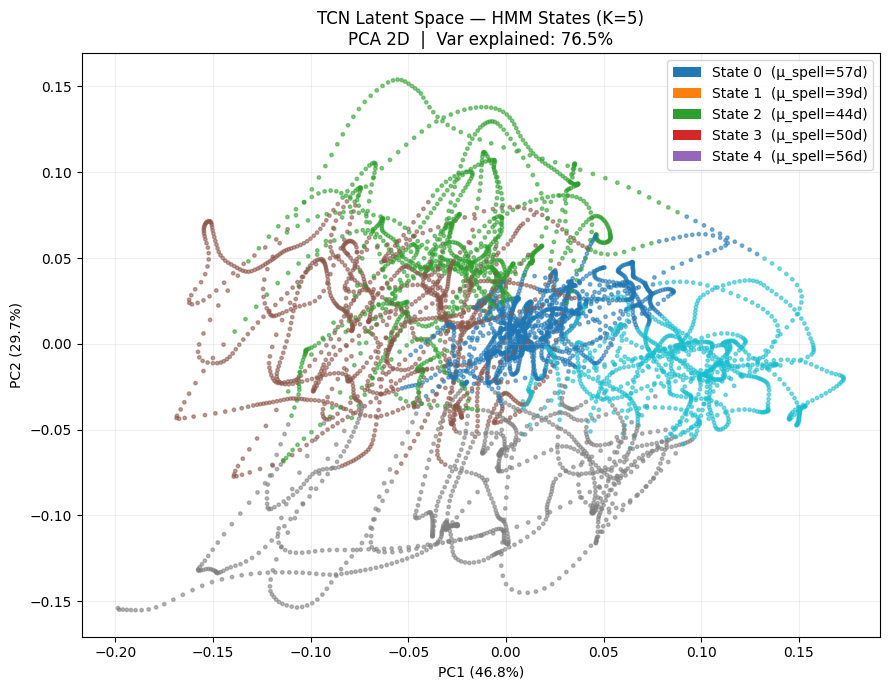

In [25]:
pca       = PCA(n_components=2, random_state=42)
latent_2d = pca.fit_transform(latent_embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    latent_2d[:, 0], latent_2d[:, 1],
    c=viterbi_states, cmap='tab10', vmin=0, vmax=optimal_K - 1,
    s=6, alpha=0.55
)
handles = [
    mpatches.Patch(facecolor=plt.cm.tab10(k),
                   label=f'State {k}  (μ_spell={spell_stats.loc[k, "Mean Spell"]:.0f}d)')
    for k in range(optimal_K)
]
ax.legend(handles=handles, fontsize=10, loc='upper right')
ax.set_title(
    f'TCN Latent Space — HMM States (K={optimal_K})\n'
    f'PCA 2D  |  Var explained: {pca.explained_variance_ratio_.sum()*100:.1f}%', fontsize=12
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ch3_latent_pca_regimes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Regime Profiling & Data Export

In [26]:
profile_df = df_smooth.loc[latent_dates].copy()
profile_df['hmm_state'] = viterbi_states

tci_by_state = profile_df.groupby('hmm_state')['TCI'].mean().sort_values(ascending=False)
print("Mean TCI per state (high → low):")
print(tci_by_state.to_frame(name='Mean TCI').to_string())

# States ranked by mean TCI: highest TCI = most stressed
ECONOMIC_LABELS = [
    'Crisis / High-Stress',
    'Elevated Stress',
    'Moderate Stress',
    'Mildly Elevated',
    'Normal / Tranquil',
]

tci_sorted_states = tci_by_state.index.tolist()
label_map = {}
for rank, state in enumerate(tci_sorted_states):
    label_map[state] = ECONOMIC_LABELS[rank] if rank < len(ECONOMIC_LABELS) else f'Intermediate (Rank {rank})'

print("\nLabel assignment:")
for state, label in sorted(label_map.items()):
    print(f"  State {state} → '{label}'  (Mean TCI = {tci_by_state[state]:.3f})")

Mean TCI per state (high → low):
            Mean TCI
hmm_state           
1          52.303468
3          48.694197
0          48.022613
2          47.169897
4          45.885884

Label assignment:
  State 0 → 'Moderate Stress'  (Mean TCI = 48.023)
  State 1 → 'Crisis / High-Stress'  (Mean TCI = 52.303)
  State 2 → 'Mildly Elevated'  (Mean TCI = 47.170)
  State 3 → 'Elevated Stress'  (Mean TCI = 48.694)
  State 4 → 'Normal / Tranquil'  (Mean TCI = 45.886)


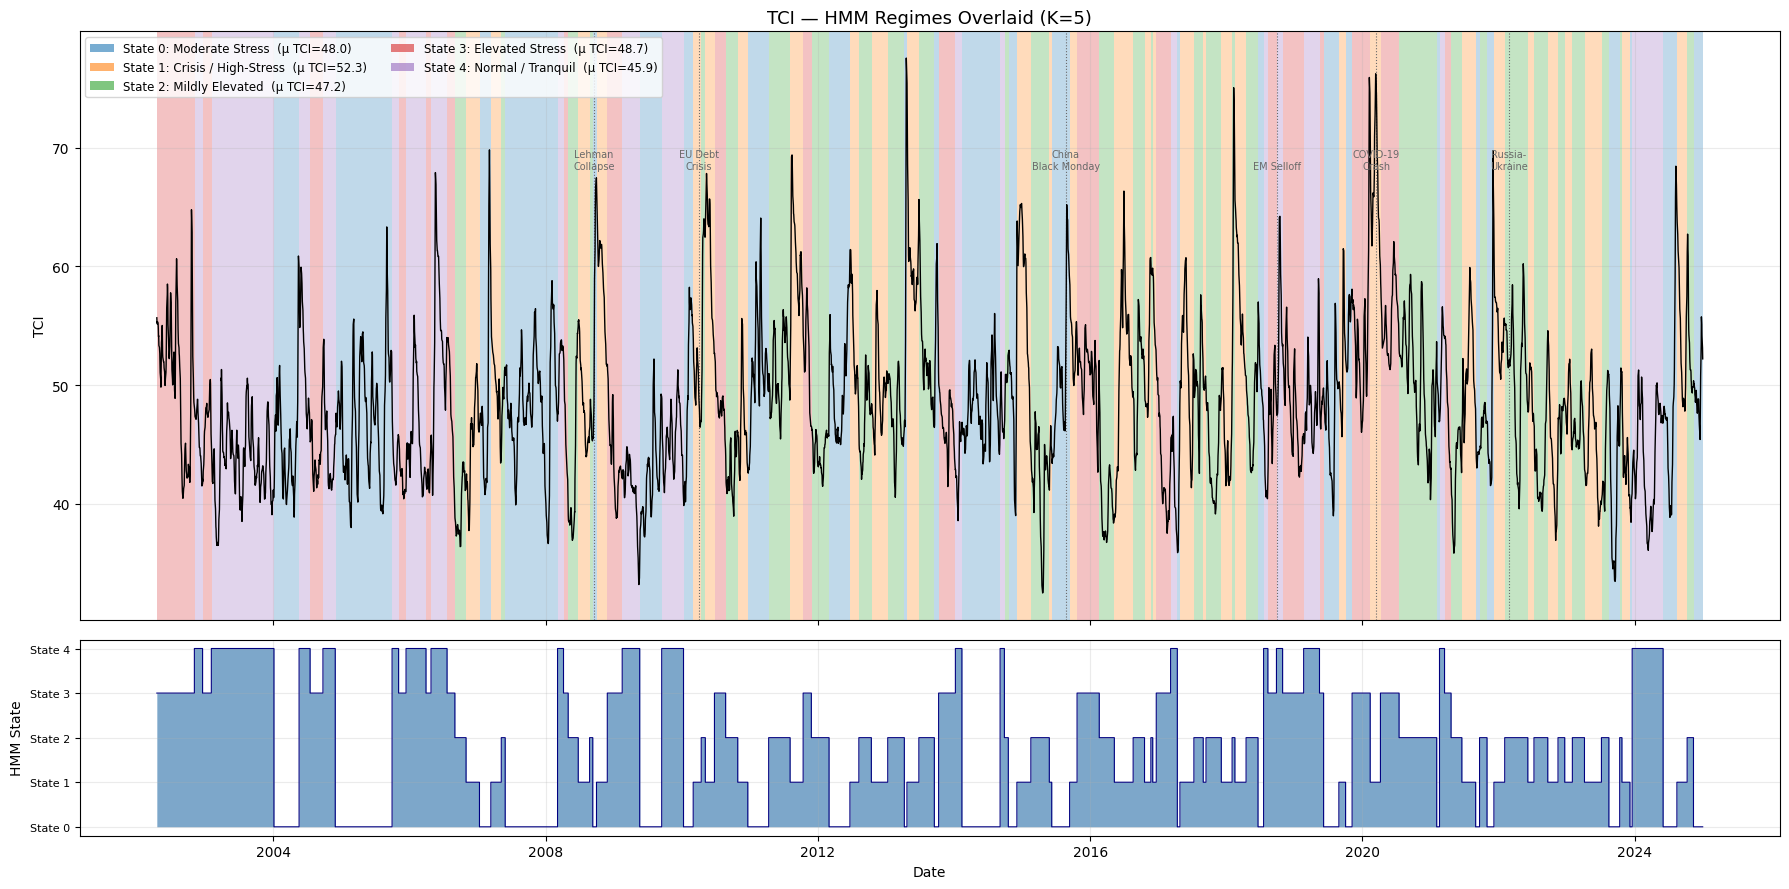

In [27]:
EVENTS = {
    '2008-09-15': 'Lehman\nCollapse',
    '2010-04-01': 'EU Debt\nCrisis',
    '2015-08-24': 'China\nBlack Monday',
    '2018-10-01': 'EM Selloff',
    '2020-03-16': 'COVID-19\nCrash',
    '2022-02-24': 'Russia-\nUkraine',
}

state_palette = {k: plt.cm.tab10(k) for k in range(optimal_K)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

tci_series = profile_df['TCI']
ax1.plot(tci_series.index, tci_series.values, color='black', lw=1.0, zorder=3)

prev_state = viterbi_states[0]
start_date = latent_dates[0]
for i in range(1, len(viterbi_states)):
    if viterbi_states[i] != prev_state or i == len(viterbi_states) - 1:
        end_date = latent_dates[i]
        ax1.axvspan(start_date, end_date, color=state_palette[prev_state], alpha=0.28, lw=0)
        start_date = latent_dates[i]
        prev_state = viterbi_states[i]

ax1.set_title(f'TCI — HMM Regimes Overlaid (K={optimal_K})', fontsize=13)
ax1.set_ylabel('TCI')
ax1.grid(alpha=0.25)

handles = [
    mpatches.Patch(facecolor=state_palette[k], alpha=0.6,
                   label=f"State {k}: {label_map[k]}  (μ TCI={tci_by_state[k]:.1f})")
    for k in range(optimal_K)
]
ax1.legend(handles=handles, loc='upper left', fontsize=8.5, ncol=2)

for date_str, label in EVENTS.items():
    try:
        ev_date = pd.to_datetime(date_str)
        if tci_series.index.min() <= ev_date <= tci_series.index.max():
            ax1.axvline(ev_date, color='dimgray', lw=0.8, linestyle=':')
            ax1.text(ev_date, tci_series.max() * 0.88, label,
                     fontsize=7, ha='center', color='dimgray')
    except Exception:
        pass

ax2.fill_between(latent_dates, viterbi_states, step='mid', alpha=0.7, color='steelblue', lw=0)
ax2.plot(latent_dates, viterbi_states, drawstyle='steps-mid', color='navy', lw=0.8)
ax2.set_yticks(range(optimal_K))
ax2.set_yticklabels([f'State {k}' for k in range(optimal_K)], fontsize=8)
ax2.set_ylabel('HMM State')
ax2.set_xlabel('Date')
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ch4_regime_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()

In [28]:
KEY_FEATURES = ['TCI', 'TO_SP500', 'TO_JCI', 'FROM_SP500', 'FROM_JCI',
                'NET_SP500', 'NET_JCI', 'TO_VIX', 'FROM_VIX']
key_feats = [f for f in KEY_FEATURES if f in profile_df.columns]

summary = profile_df[key_feats + ['hmm_state']].groupby('hmm_state').agg(['mean', 'std'])
summary.columns = [f'{col}_{stat}' for col, stat in summary.columns]

display_rows = []
for state in range(optimal_K):
    row = {'State': state, 'Label': label_map[state], 'N Days': int((viterbi_states == state).sum())}
    for feat in key_feats:
        row[feat] = f"{summary.loc[state, f'{feat}_mean']:.2f} ± {summary.loc[state, f'{feat}_std']:.2f}"
    display_rows.append(row)

summary_table = pd.DataFrame(display_rows).set_index('State')
print(summary_table.to_string())

summary_table.to_csv(os.path.join(OUTPUT_DIR, 'regime_summary_statistics.csv'))
print(f"\nSaved: regime_summary_statistics.csv")

                      Label  N Days           TCI     TO_SP500       TO_JCI   FROM_SP500     FROM_JCI     NET_SP500       NET_JCI       TO_VIX     FROM_VIX
State                                                                                                                                                      
0           Moderate Stress    1434  48.02 ± 5.98  5.95 ± 2.15  7.40 ± 2.50  7.38 ± 1.27  6.93 ± 1.11  -1.43 ± 2.34   0.48 ± 2.74  5.79 ± 2.68  6.66 ± 1.21
1      Crisis / High-Stress    1205  52.30 ± 7.22  8.19 ± 2.74  6.24 ± 2.49  7.97 ± 1.47  7.79 ± 1.53   0.22 ± 3.18  -1.55 ± 2.93  7.56 ± 3.68  7.11 ± 1.26
2           Mildly Elevated    1324  47.17 ± 5.89  6.81 ± 2.39  5.68 ± 2.15  7.25 ± 1.20  7.02 ± 1.27  -0.44 ± 2.54  -1.33 ± 2.51  6.39 ± 2.50  6.43 ± 1.30
3           Elevated Stress     940  48.69 ± 5.45  6.51 ± 1.96  6.85 ± 2.25  7.27 ± 1.29  7.09 ± 1.19  -0.76 ± 2.44  -0.24 ± 2.69  6.31 ± 2.57  6.78 ± 1.20
4         Normal / Tranquil    1001  45.89 ± 5.30  5.68 ± 1.82  

In [29]:
# Table 4.1 — Transition Matrix
# best_hmm.transmat_[i, j] = P(state_j | state_i)
trans_df = pd.DataFrame(
    best_hmm.transmat_,
    index  =[f'State {k} ({label_map[k]})' for k in range(optimal_K)],
    columns=[f'State {k} ({label_map[k]})' for k in range(optimal_K)],
).round(4)

print("HMM Transition Matrix  P(next | current):")
print(trans_df.to_string())

trans_df.to_csv(os.path.join(OUTPUT_DIR, 'transition_matrix.csv'))
print(f"\nSaved: transition_matrix.csv")

HMM Transition Matrix  P(next | current):
                                State 0 (Moderate Stress)  State 1 (Crisis / High-Stress)  State 2 (Mildly Elevated)  State 3 (Elevated Stress)  State 4 (Normal / Tranquil)
State 0 (Moderate Stress)                          0.9832                          0.0078                     0.0020                     0.0013                       0.0056
State 1 (Crisis / High-Stress)                     0.0051                          0.9740                     0.0159                     0.0051                       0.0000
State 2 (Mildly Elevated)                          0.0082                          0.0144                     0.9773                     0.0000                       0.0000
State 3 (Elevated Stress)                          0.0008                          0.0011                     0.0078                     0.9794                       0.0109
State 4 (Normal / Tranquil)                        0.0072                          0.0000    

In [30]:
# Table 4.2 — Regime Characteristics (thesis-ready format)
rows = []
for k in range(optimal_K):
    mask   = viterbi_states == k
    n_days = int(mask.sum())
    pct    = n_days / len(viterbi_states) * 100

    tci_vals = profile_df.loc[latent_dates[mask], 'TCI']

    rows.append({
        'State'          : k,
        'Label'          : label_map[k],
        'N Days'         : n_days,
        'Frequency (%)'  : round(pct, 1),
        'TCI Mean'       : round(tci_vals.mean(), 4),
        'TCI Std'        : round(tci_vals.std(),  4),
        'Mean Spell (d)' : spell_stats.loc[k, 'Mean Spell'],
        'Median Spell (d)': spell_stats.loc[k, 'Median Spell'],
        'Max Spell (d)'  : spell_stats.loc[k, 'Max Spell'],
    })

regime_char = pd.DataFrame(rows).set_index('State')
print("Regime Characteristics:")
print(regime_char.to_string())

regime_char.to_csv(os.path.join(OUTPUT_DIR, 'regime_characteristics.csv'))
print(f"\nSaved: regime_characteristics.csv")

Regime Characteristics:
                      Label  N Days  Frequency (%)  TCI Mean  TCI Std  Mean Spell (d)  Median Spell (d)  Max Spell (d)
State                                                                                                                 
0           Moderate Stress    1434           24.3   48.0226   5.9756            57.4              37.0            218
1      Crisis / High-Stress    1205           20.4   52.3035   7.2210            38.9              39.0             73
2           Mildly Elevated    1324           22.4   47.1699   5.8873            44.1              42.5            143
3           Elevated Stress     940           15.9   48.6942   5.4483            49.5              42.0            145
4         Normal / Tranquil    1001           17.0   45.8859   5.2999            55.6              37.0            239

Saved: regime_characteristics.csv


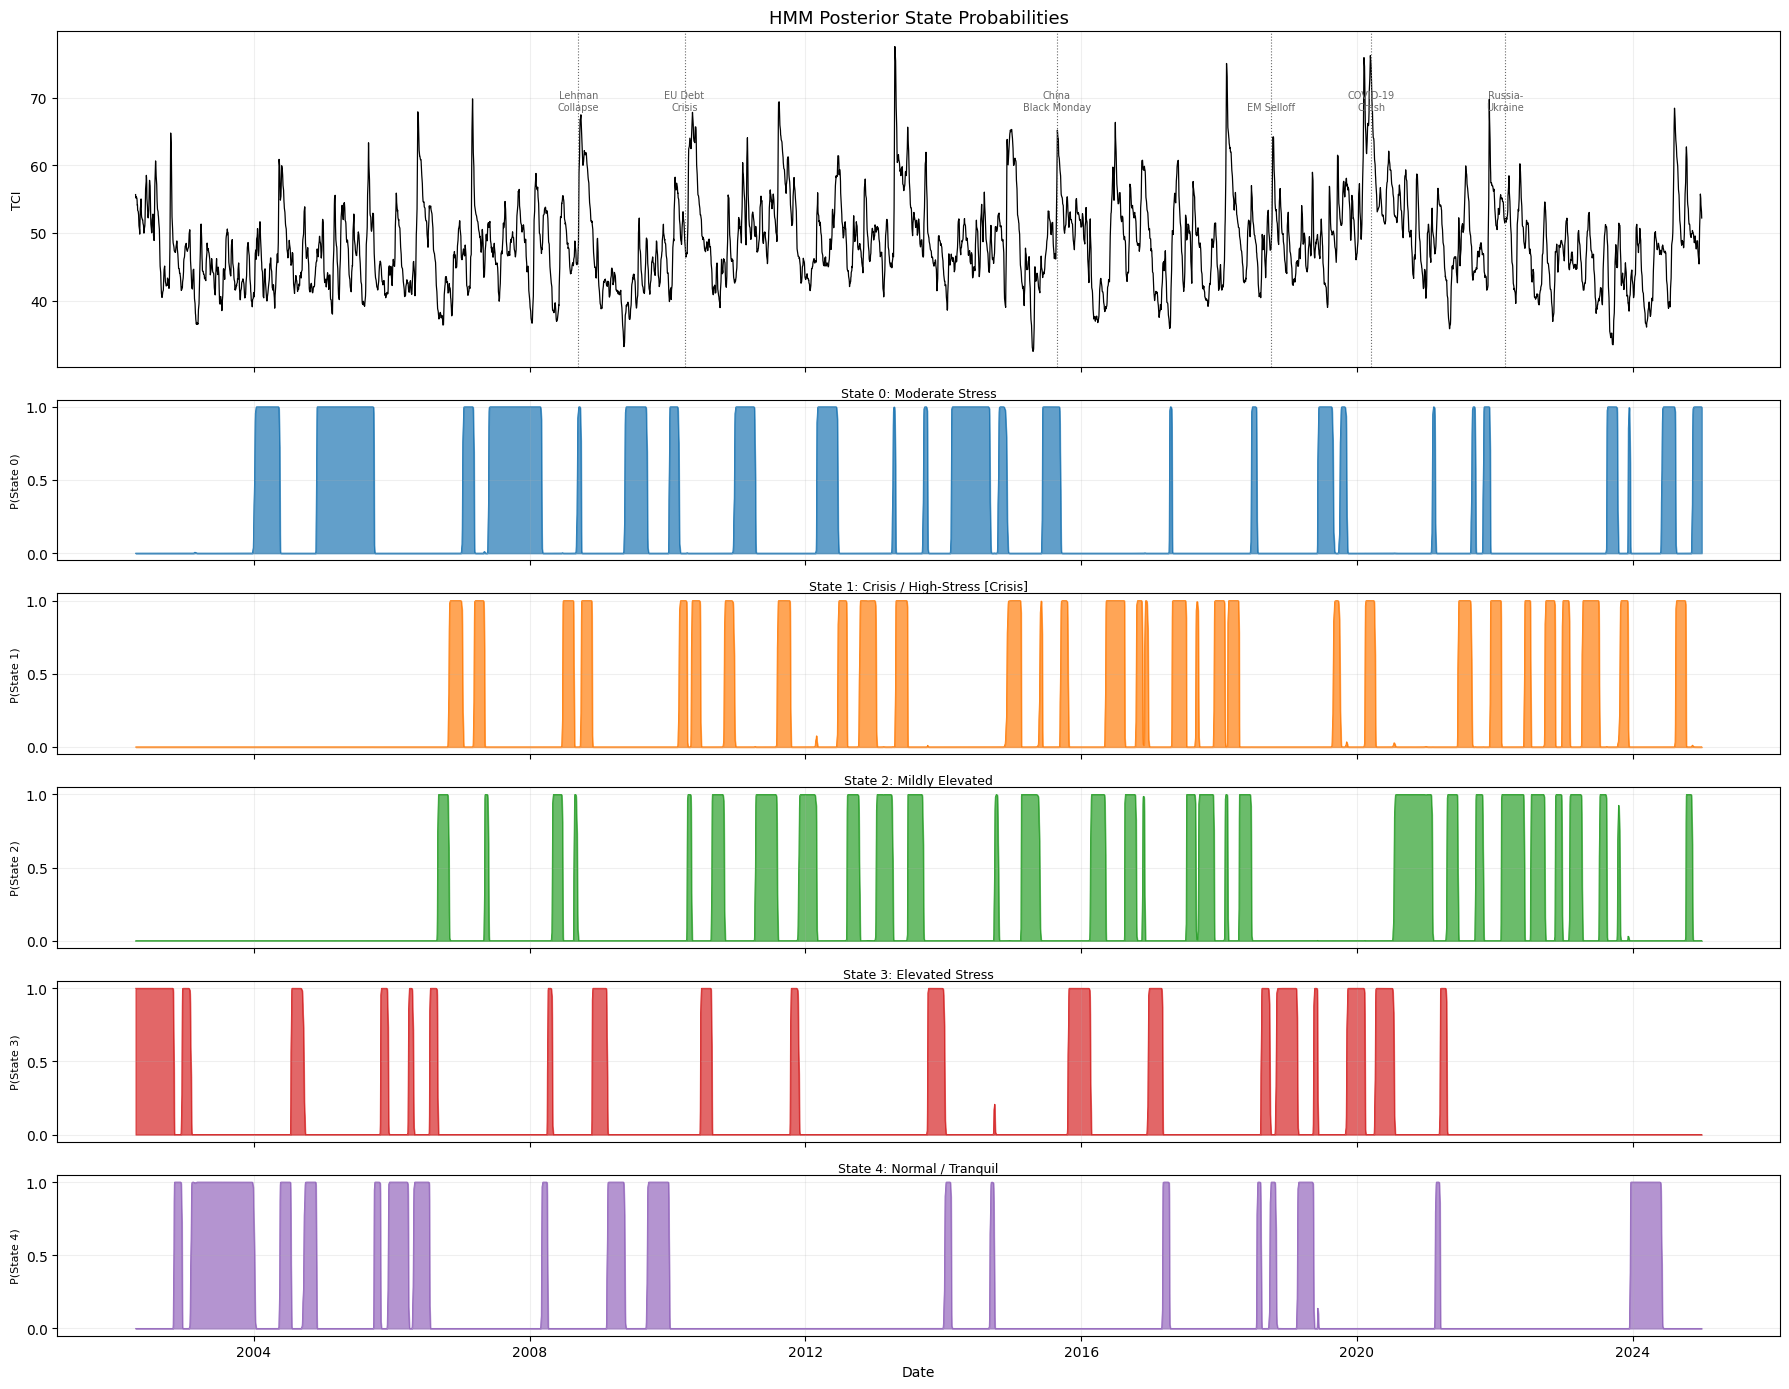

Saved: hmm_regime_probabilities.png


In [31]:
# Figure 4.4 — HMM Posterior State Probabilities
# predict_proba returns P(state_k | observations_{1..T}), shape (T, K)
posterior_probs = best_hmm.predict_proba(latent_embeddings)  # (T, K)

# Identify the "most stressed" state index (highest mean TCI)
crisis_state = tci_sorted_states[0]

fig, axes = plt.subplots(optimal_K + 1, 1, figsize=(18, 4 + 2 * optimal_K),
                          sharex=True, gridspec_kw={'height_ratios': [2.5] + [1.2] * optimal_K})

# Top panel: TCI for context
axes[0].plot(latent_dates, profile_df['TCI'], color='black', lw=0.9)
for date_str, label in EVENTS.items():
    try:
        ev = pd.to_datetime(date_str)
        if latent_dates.min() <= ev <= latent_dates.max():
            axes[0].axvline(ev, color='dimgray', lw=0.8, linestyle=':')
            axes[0].text(ev, profile_df['TCI'].max() * 0.88, label, fontsize=7, ha='center', color='dimgray')
    except Exception:
        pass
axes[0].set_ylabel('TCI', fontsize=9)
axes[0].set_title('HMM Posterior State Probabilities', fontsize=13)
axes[0].grid(alpha=0.2)

# One panel per state
for k in range(optimal_K):
    ax = axes[k + 1]
    color = state_palette[k]
    ax.fill_between(latent_dates, posterior_probs[:, k], alpha=0.7, color=color)
    ax.plot(latent_dates, posterior_probs[:, k], color=color, lw=0.6)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(f'P(State {k})', fontsize=8)
    ax.set_yticks([0, 0.5, 1])
    ax.grid(alpha=0.2)
    crisis_tag = ' [Crisis]' if k == crisis_state else ''
    ax.set_title(f'State {k}: {label_map[k]}{crisis_tag}', fontsize=9, pad=2)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hmm_regime_probabilities.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hmm_regime_probabilities.png")

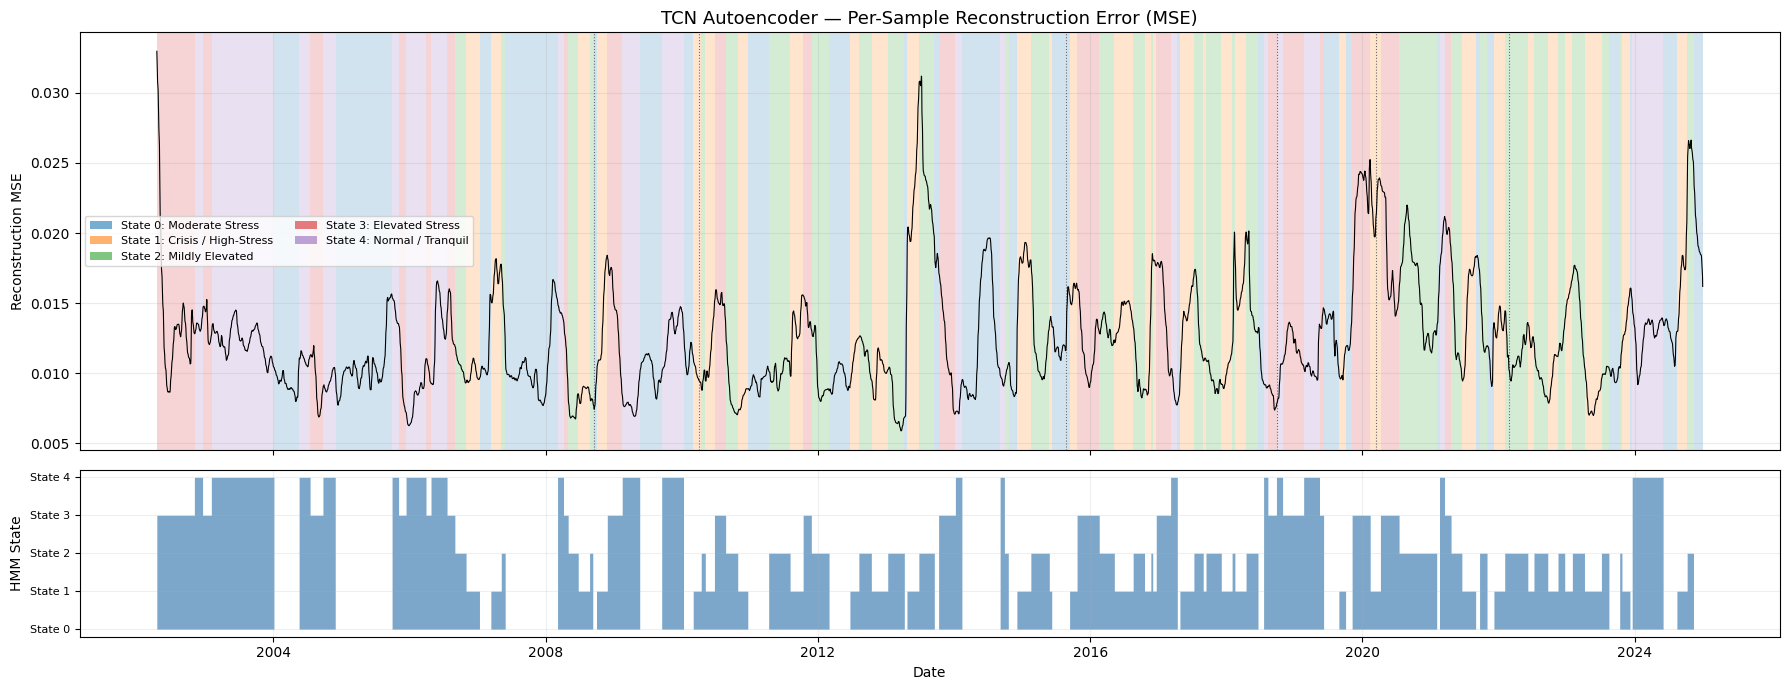

Saved: tcn_reconstruction_error.png
Saved: tcn_reconstruction_error.csv


In [32]:
# Figure 4.5 — TCN Per-Timestep Reconstruction Error
# Compute MSE for each sliding window sample aligned to latent_dates
model.eval()
recon_errors = []

with torch.no_grad():
    for x_batch, _ in full_loader:
        x_b   = x_batch.to(device)
        recon = model(x_b)
        # MSE per sample: mean over (LOOKBACK, n_features)
        mse   = ((x_b - recon) ** 2).mean(dim=(1, 2))
        recon_errors.extend(mse.cpu().numpy().tolist())

recon_errors = np.array(recon_errors)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1]})

# Top: reconstruction error coloured by regime
ax1.plot(latent_dates, recon_errors, color='black', lw=0.8, zorder=3)
prev_state = viterbi_states[0]
start_date = latent_dates[0]
for i in range(1, len(viterbi_states)):
    if viterbi_states[i] != prev_state or i == len(viterbi_states) - 1:
        end_date = latent_dates[i]
        ax1.axvspan(start_date, end_date, color=state_palette[prev_state], alpha=0.20, lw=0)
        start_date = latent_dates[i]
        prev_state = viterbi_states[i]
ax1.set_title('TCN Autoencoder — Per-Sample Reconstruction Error (MSE)', fontsize=13)
ax1.set_ylabel('Reconstruction MSE')
ax1.grid(alpha=0.25)
handles = [mpatches.Patch(facecolor=state_palette[k], alpha=0.6,
                           label=f'State {k}: {label_map[k]}') for k in range(optimal_K)]
ax1.legend(handles=handles, fontsize=8, ncol=2)

for date_str, label in EVENTS.items():
    try:
        ev = pd.to_datetime(date_str)
        if latent_dates.min() <= ev <= latent_dates.max():
            ax1.axvline(ev, color='dimgray', lw=0.8, linestyle=':')
    except Exception:
        pass

# Bottom: regime state bar
ax2.fill_between(latent_dates, viterbi_states, step='mid', alpha=0.7, color='steelblue', lw=0)
ax2.set_yticks(range(optimal_K))
ax2.set_yticklabels([f'State {k}' for k in range(optimal_K)], fontsize=8)
ax2.set_ylabel('HMM State')
ax2.set_xlabel('Date')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tcn_reconstruction_error.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tcn_reconstruction_error.png")

# Optional: save the error series as CSV for downstream analysis
recon_df = pd.DataFrame({'recon_mse': recon_errors, 'hmm_state': viterbi_states}, index=latent_dates)
recon_df.index.name = 'Date'
recon_df.to_csv(os.path.join(OUTPUT_DIR, 'tcn_reconstruction_error.csv'))
print("Saved: tcn_reconstruction_error.csv")

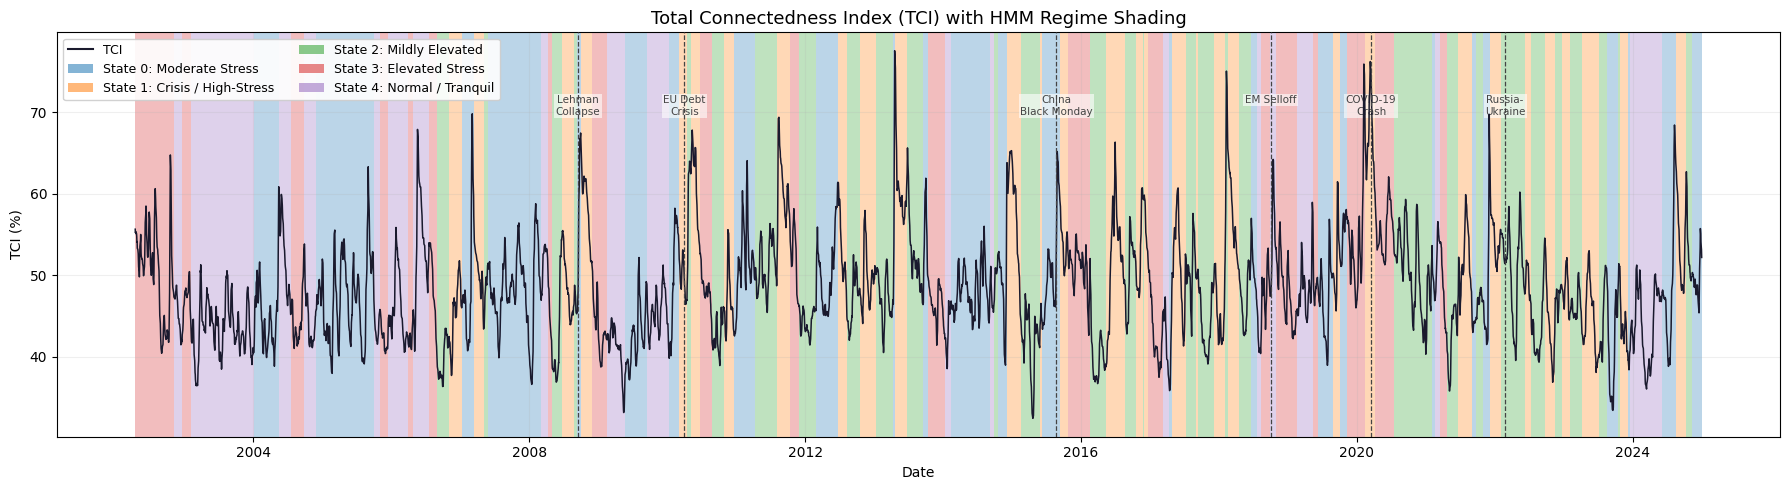

Saved: regime_overlay_tci.png
Note: Use this figure as Figure 4.6 in the thesis (TCI proxy for systemic risk).


In [33]:
# Figure 4.6 — Regime overlay on TCI (thesis thesis-ready single-panel version)
# Note: JCI price is not part of the connectedness feature set used as model input.
# TCI (Total Connectedness Index) serves as the primary systemic-risk series here.
# When writing the thesis, this can be described as "TCI with HMM Regime Shading".

crisis_color  = state_palette[crisis_state]
tranquil_state = tci_sorted_states[-1]  # lowest mean TCI = most tranquil

fig, ax = plt.subplots(figsize=(18, 5))

tci_series = profile_df['TCI']
ax.plot(tci_series.index, tci_series.values, color='#1a1a2e', lw=1.1, zorder=4, label='TCI')

# Shade background by regime
prev_state = viterbi_states[0]
start_date = latent_dates[0]
for i in range(1, len(viterbi_states)):
    if viterbi_states[i] != prev_state or i == len(viterbi_states) - 1:
        end_date  = latent_dates[i]
        ax.axvspan(start_date, end_date, color=state_palette[prev_state], alpha=0.30, lw=0)
        start_date = latent_dates[i]
        prev_state = viterbi_states[i]

# Event markers
for date_str, label in EVENTS.items():
    try:
        ev = pd.to_datetime(date_str)
        if tci_series.index.min() <= ev <= tci_series.index.max():
            ax.axvline(ev, color='#444', lw=0.9, linestyle='--', zorder=5)
            ax.text(ev, tci_series.max() * 0.93, label,
                    fontsize=7.5, ha='center', va='top', color='#444',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))
    except Exception:
        pass

handles = [mpatches.Patch(facecolor=state_palette[k], alpha=0.55,
                           label=f'State {k}: {label_map[k]}') for k in range(optimal_K)]
handles = [plt.Line2D([0], [0], color='#1a1a2e', lw=1.5, label='TCI')] + handles
ax.legend(handles=handles, loc='upper left', fontsize=9, ncol=2, framealpha=0.9)

ax.set_title('Total Connectedness Index (TCI) with HMM Regime Shading', fontsize=13)
ax.set_ylabel('TCI (%)')
ax.set_xlabel('Date')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'regime_overlay_tci.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: regime_overlay_tci.png")
print("Note: Use this figure as Figure 4.6 in the thesis (TCI proxy for systemic risk).")

In [34]:
export_df = regime_df[['hmm_state']].copy()
export_df.index.name = 'Date'
export_df.to_csv(OUTPUT_PATH)

print(f"File   : {OUTPUT_PATH}")
print(f"Shape  : {export_df.shape}")
print(f"Dates  : {export_df.index.min().date()}  →  {export_df.index.max().date()}")
print(f"States : {sorted(export_df['hmm_state'].unique())}")
print()
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fsize = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    print(f"  {fname:<45}  ({fsize:,} bytes)")

export_df.head(10)

File   : /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/HMM-TCN/hmm_regimes.csv
Shape  : (5904, 1)
Dates  : 2002-04-15  →  2024-12-31
States : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

  ch1_tci_smoothing_comparison.png               (326,293 bytes)
  ch2_tcn_training_loss.png                      (66,296 bytes)
  ch3_hmm_bic_selection.png                      (59,612 bytes)
  ch3_latent_pca_regimes.png                     (615,713 bytes)
  ch4_regime_timeline.png                        (455,011 bytes)
  hmm_regime_probabilities.png                   (542,068 bytes)
  hmm_regimes.csv                                (76,767 bytes)
  regime_characteristics.csv                     (385 bytes)
  regime_overlay_tci.png                         (335,202 bytes)
  regime_summary_statistics.csv                  (811 bytes)
  tcn_autoencoder_best.pt                        (119,477 bytes)
  tcn_recons

,hmm_state
Date,
2002-04-15,3
2002-04-16,3
2002-04-17,3
2002-04-18,3
2002-04-19,3
2002-04-22,3
2002-04-23,3
2002-04-24,3
2002-04-25,3
